In [3]:
from scipy import stats
from statsmodels.stats.weightstats import ztest
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
import numpy as np
import statistics as st
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

data = pd.read_csv('nba_second_round_history_modified.csv')

We'd like to further test if the Champion teams have higher stats like Avg Points Allowed and other important features we captured using the model from the previous section.

In [4]:
print("Shape:", data.shape)
print("Seasons:", data["Season"].min(), "-", data["Season"].max())
print("Number of seasons:", data["Season"].nunique())
print("Champion counts:")
print(data["Champion"].value_counts())
data.head()

Shape: (168, 29)
Seasons: 1984 - 2025
Number of seasons: 42
Champion counts:
Champion
False    126
True      42
Name: count, dtype: int64


,Season,Team,Opponent,Games played,Average Points scored,Average Points allowed,Offensive Rating,Defensive Rating,eFG%,Opp eFG%,...,eFG% Difference,TOV% Difference,ORB% Difference,FT/FGA Difference,Actual Wins (%),Pythagorean Wins (13.91) (%),Pythagorean Wins (16.5) (%),TS% Difference,Team TS%,Opp TS%
0,1984,BOS,NYK,7,111.0,103.0,113.9,105.7,0.498,0.484,...,1.4,-1.8,3.7,-0.011,57.143,73.894,77.456,0.978,54.9350,53.9574
1,1984,MIL,NJN,6,98.2,96.3,102.8,100.9,0.471,0.405,...,6.6,6.1,-2.9,0.033,66.667,56.753,57.990,6.868,54.0129,47.1452
2,1984,LAL,DAL,5,120.6,106.2,121.9,107.4,0.570,0.454,...,11.6,0.9,2.7,-0.032,80.000,85.430,89.071,9.349,59.7550,50.4063
3,1984,PHO,UTA,6,103.7,101.0,107.0,104.3,0.462,0.468,...,-0.6,-2.4,1.5,-0.070,66.667,59.073,60.714,-1.444,51.2187,52.6627
4,1985,BOS,DET,6,120.5,112.7,118.1,110.4,0.519,0.478,...,4.1,2.2,1.4,0.106,66.667,71.725,75.104,6.197,57.8882,51.6914


# descripitive

In [5]:
# descriptive 
champs = data[data["Champion"] == True]
non_champs = data[data["Champion"] == False]
point_diff_champ = champs["Average Points Difference"].dropna()
point_diff_non_champ = non_champs["Average Points Difference"].dropna()

desc_q2 = pd.DataFrame({
    "Group": ["Champion", "Non-Champion"],
    "n": [len(point_diff_champ), len(point_diff_non_champ)],
    "Mean": [point_diff_champ.mean(), point_diff_non_champ.mean()],
    "SD": [point_diff_champ.std(ddof=1), point_diff_non_champ.std(ddof=1)],
    "Median": [point_diff_champ.median(), point_diff_non_champ.median()],
    "Min": [point_diff_champ.min(), point_diff_non_champ.min()],
    "Max": [point_diff_champ.max(), point_diff_non_champ.max()]
})

desc_q2

,Group,n,Mean,SD,Median,Min,Max
0,Champion,42,7.207143,4.214168,7.7,-2.8,15.0
1,Non-Champion,126,4.859524,4.695771,4.1,-3.2,25.3


# F test (the F-test does not show a significant difference in variances)

In [6]:
var_champ = point_diff_champ.var(ddof=1)
var_non_champ = point_diff_non_champ.var(ddof=1)

#  bigger var at numerator
if var_champ >= var_non_champ:
    F = var_champ / var_non_champ
    df1 = len(point_diff_champ) - 1
    df2 = len(point_diff_non_champ) - 1
else:
    F = var_non_champ / var_champ
    df1 = len(point_diff_non_champ) - 1
    df2 = len(point_diff_champ) - 1

p_one_tail = 1 - stats.f.cdf(F, df1, df2)
p_two_tail = 2 * p_one_tail

print("Champion variance:", var_champ)
print("Non-champion variance:", var_non_champ)
print("F statistic:", F)
print("df1:", df1, "df2:", df2)
print("Two-sided p-value:", p_two_tail)

Champion variance: 17.759216027874565
Non-champion variance: 22.050268571428568
F statistic: 1.241623984798588
df1: 125 df2: 41
Two-sided p-value: 0.43034568928689754


# Welch's t-test (Welch’s t-test shows that this difference is statistically significant.)

In [9]:
# Welch's two sample t-test
welch_result = stats.ttest_ind(
    point_diff_champ,
    point_diff_non_champ,
    equal_var=False,
    alternative="greater"
)

print("Welch's t-test")
print("t-statistic:", welch_result.statistic)
print("p-value:", welch_result.pvalue)

Welch's t-test
t-statistic: 3.036231760881159
p-value: 0.001630337211237078


# Pooled t-test (Pooled t-test also show significance difference)

In [10]:
# Pooled two sample t-test
pooled_result = stats.ttest_ind(
    point_diff_champ,
    point_diff_non_champ,
    equal_var=True,
    alternative="greater"
)

print("Pooled two sample t-test")
print("t-statistic:", pooled_result.statistic)
print("p-value:", pooled_result.pvalue)

Pooled two sample t-test
t-statistic: 2.87588973520451
p-value: 0.0022787975267969385


# Addional: Cohen's d 

In [11]:
# Cohen's d effect size
n1 = len(point_diff_champ)
n2 = len(point_diff_non_champ)

s1 = point_diff_champ.std(ddof=1)
s2 = point_diff_non_champ.std(ddof=1)

pooled_sd = np.sqrt(
    ((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)
)

cohen_d = (point_diff_champ.mean() - point_diff_non_champ.mean()) / pooled_sd

print("Cohen's d:", cohen_d)

Cohen's d: 0.5124092414893004


# Summary

In [12]:
summary_q2 = pd.DataFrame({
    "Test": [
        "F-test for equal variances",
        "Welch's t-test",
        "Pooled two-sample t-test",
        "Cohen's d"
    ],
    "Statistic": [
        F,
        welch_result.statistic,
        pooled_result.statistic,
        cohen_d
    ],
    "p-value": [
        p_two_tail,
        welch_result.pvalue,
        pooled_result.pvalue,
        np.nan
    ],
    "Role": [
        "Diagnostic check for equal variances",
        "Main test for mean difference",
        "Robustness check assuming equal variances",
        "Effect size for practical difference"
    ]
})
summary_q2

,Test,Statistic,p-value,Role
0,F-test for equal variances,1.241624,0.430346,Diagnostic check for equal variances
1,Welch's t-test,3.036232,0.001630,Main test for mean difference
2,Pooled two-sample t-test,2.875890,0.002279,Robustness check assuming equal variances
3,Cohen's d,0.512409,NaN,Effect size for practical difference


<Figure size 700x500 with 0 Axes>

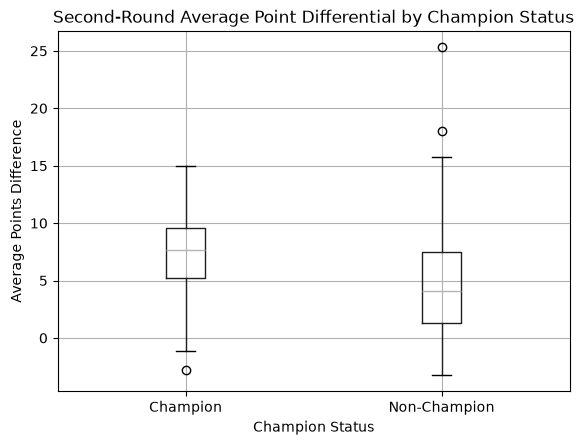

In [15]:
plot_data = data.copy()
plot_data["Champion Status"] = plot_data["Champion"].map({
    False: "Non-Champion",
    True: "Champion"
})
plt.figure(figsize=(7, 5))
plot_data.boxplot(column="Average Points Difference", by="Champion Status")
plt.title("Second-Round Average Point Differential by Champion Status")
plt.suptitle("")
plt.xlabel("Champion Status")
plt.ylabel("Average Points Difference")
plt.show()

### Q2 Conclusion

For the second research question, we compare the second-round average point differential between eventual champions and non-champions.

From the descriptive statistics, champion teams had a higher mean second-round average point differential than non-champion teams. Champions had an average point differential of 7.21 points per game, while non-champions had an average point differential of 4.86 points per game.

Before performing the t-test, we conducted an F-test to check whether the two groups had equal variances. The F-test result was not significant, with p = 0.430, suggesting that there is no strong evidence that the two variances are different. However, because the champion group and non-champion group have unequal sample sizes, we used Welch’s two sample t-test as the main test.

The Welch’s t-test result was significant, with t = 3.036 and p = 0.00163. Therefore, we reject the null hypothesis at α = 0.05. This suggests that eventual NBA champions had a significantly higher second-round average point differential than non-champions.

The pooled two sample t-test was also conducted as a robustness check, and it gave a consistent result, with t = 2.876 and p = 0.00228. In addition, Cohen’s d was about 0.51, suggesting a moderate effect size. Overall, the results support the idea that stronger second-round scoring-margin dominance is associated with a higher chance of eventually winning the NBA championship.